In [4]:
import numpy as np
import pandas as pd
import itertools as itt

# Источник для CPCV - de Prado Advances in Financial Machine Learning


def purge(t1, test_times):
    """Удаляет из обучающей выборки наблюдения, перекрывающиеся с тестовой.

    t1 — Series, индекс = начало наблюдения, значение = конец метки.
    test_times — Series, индекс = начало теста, значение = конец теста.
    """
    train = t1.copy(deep=True)
    for start, end in test_times.items():
        df_0 = train[(start <= train.index) & (train.index <= end)].index
        df_1 = train[(start <= train) & (train <= end)].index
        train = train.drop(df_0.union(df_1))
    return train


def _embargo_shift(times, pct_embargo):
    """Сдвигает конечные метки вперёд на pct_embargo * len(times)."""
    step = int(times.shape[0] * pct_embargo)
    if step == 0:
        return pd.Series(times, index=times)
    ans = pd.Series(times[step:].values, index=times[:-step])
    ans = pd.concat([ans, pd.Series(times[-1], index=times[-step:])])
    return ans


def embargo(test_times, t1, pct_embargo=0.01):
    """Расширяет тестовые интервалы на эмбарго-период.

    Это предотвращает утечку информации из-за автокорреляции
    вблизи границ тестовой выборки.
    """
    t1_embargo = _embargo_shift(t1.index, pct_embargo)
    test_times_embargoed = t1_embargo.loc[test_times.index]
    return test_times_embargoed


def cpcv_generator(t_span, n, k):
    # 1. разбиваем моменты времени на n групп
    group_num = np.arange(t_span) // (t_span // n)
    group_num[group_num == n] = n-1

    # 2. считаем количество всевозможных симуляций и путей
    test_groups = np.array(list(itt.combinations(np.arange(n), k))).reshape(-1, k)
    C_nk = len(test_groups)
    n_paths = C_nk * k // n

    # 3. отмечаем моменты времени и группы как тестовые
    is_test_group = np.full((n, C_nk), fill_value=False)
    is_test = np.full((t_span, C_nk), fill_value=False)

    for sim_i, comb in enumerate(test_groups):
        is_test_group[comb, sim_i] = True # группа тестовая в симуляции sim_i

        mask = np.isin(group_num, comb)
        is_test[mask, sim_i] = True

    # 4. для каждого пути отмечаем из каких групп он состоит
    path_folds = np.full((n, n_paths), fill_value=np.nan) # всемозможные пути тестирования

    # для каждой группы находим симуляцию с минимальным номером,
    # в которой она тестовая
    for i in range(n_paths):
        for j in range(n):
            sim_i = is_test_group[j, :].argmax().astype(int)
            path_folds[j, i] = sim_i
            is_test_group[j, sim_i] = False

    # 5. для каждого пути отмечаем из каких моментов времени он состоит
    paths = np.full((t_span, n_paths), fill_value=np.nan)

    for p in range(n_paths):
        for i in range(n):
            mask = (group_num == i)
            paths[mask, p] = int(path_folds[i, p])

    return (is_test, paths, path_folds)




# 04. Классификация направления BTC (v2)

Построение ML-модели для предсказания бинарного направления движения цены BTC через 7 дней.

**Улучшения по сравнению с предыдущей версией:**
1. Расширенный набор признаков (FNG, EFFR, RSI, MACD, Bollinger, Hurst, корреляция BTC-SPX)
2. Чистая целевая переменная `up_30d_ahead`
3. Три модели для сравнения: XGBoost, Random Forest, BaggingClassifier
4. Полные метрики классификации: Accuracy, Precision, Recall, F1, AUC-ROC
5. Анализ важности признаков (permutation importance)

**Методология валидации:** Combinatorial Purged Cross-Validation (CPCV) с embargo.

In [5]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path("..").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, log_loss,
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve)
from sklearn.inspection import permutation_importance

np.random.seed(42)
plt.rcParams.update({"figure.figsize": (12, 5), "axes.grid": True})

In [6]:
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
    print("XGBoost доступен")
except ImportError:
    HAS_XGB = False
    print("XGBoost не установлен. Установите: pip install xgboost")
    print("Будет использован GradientBoostingClassifier как замена.")
    from sklearn.ensemble import GradientBoostingClassifier

XGBoost доступен


## 1. Загрузка данных и подготовка

Целевая переменная: $y_t = \mathbb{1}(P_{t+30} > P_t)$ — бинарная метка «цена через 30 дней выше текущей».

Бейзлайн «всегда вверх» даёт accuracy выше за счёт накопленного drift'а на месячном горизонте — точное значение зависит от выборки и считается ниже.

In [7]:
# Загрузка признаков и таргетов
features = pd.read_csv("features_v2.csv", parse_dates=["date"]).set_index("date")
targets  = pd.read_csv("targets_v1.csv",   parse_dates=["date"]).set_index("date")

# Объединяем по дате
data = features.join(targets, how="inner").dropna()
print(f"Объединённый датасет: {data.shape[0]} строк, {data.shape[1]} столбцов")

# Выбираем признаки (исключаем сырые цены — нестационарны, см. 03_Distribution_Analysis)
price_cols = ["btc_close", "btc_ma7", "btc_ma20", "btc_ma60", "spx_close", "spx_ma20"]
target_cols = [c for c in data.columns if c.startswith("ret_") or c.startswith("up_")]
feature_cols = [c for c in data.columns if c not in price_cols + target_cols]

print(f"Признаки ({len(feature_cols)}): {feature_cols}")
print(f"\nЦелевая переменная: up_30d_ahead")
print(f"Баланс классов: {data['up_30d_ahead'].value_counts().to_dict()}")
print(f"Доля класса 1 (up): {data['up_30d_ahead'].mean():.3f}")

X = data[feature_cols]
y = data["up_30d_ahead"]

Объединённый датасет: 4375 строк, 33 столбцов
Признаки (21): ['btc_ret_1d', 'btc_ret_7d', 'btc_ret_30d', 'btc_vol_20', 'btc_dist_to_ma20', 'btc_rel_vol_20', 'btc_rsi_14', 'btc_macd_hist', 'btc_bb_width', 'btc_hurst_126', 'spx_ret_1d', 'spx_ret_5d', 'spx_ret_21d', 'spx_dist_ma20', 'corr_btc_spx_60', 'fng_missing', 'fng_value', 'fng_ma7', 'fng_change_7d', 'effr_rate', 'effr_change_30d']

Целевая переменная: up_30d_ahead
Баланс классов: {1: 2387, 0: 1988}
Доля класса 1 (up): 0.546


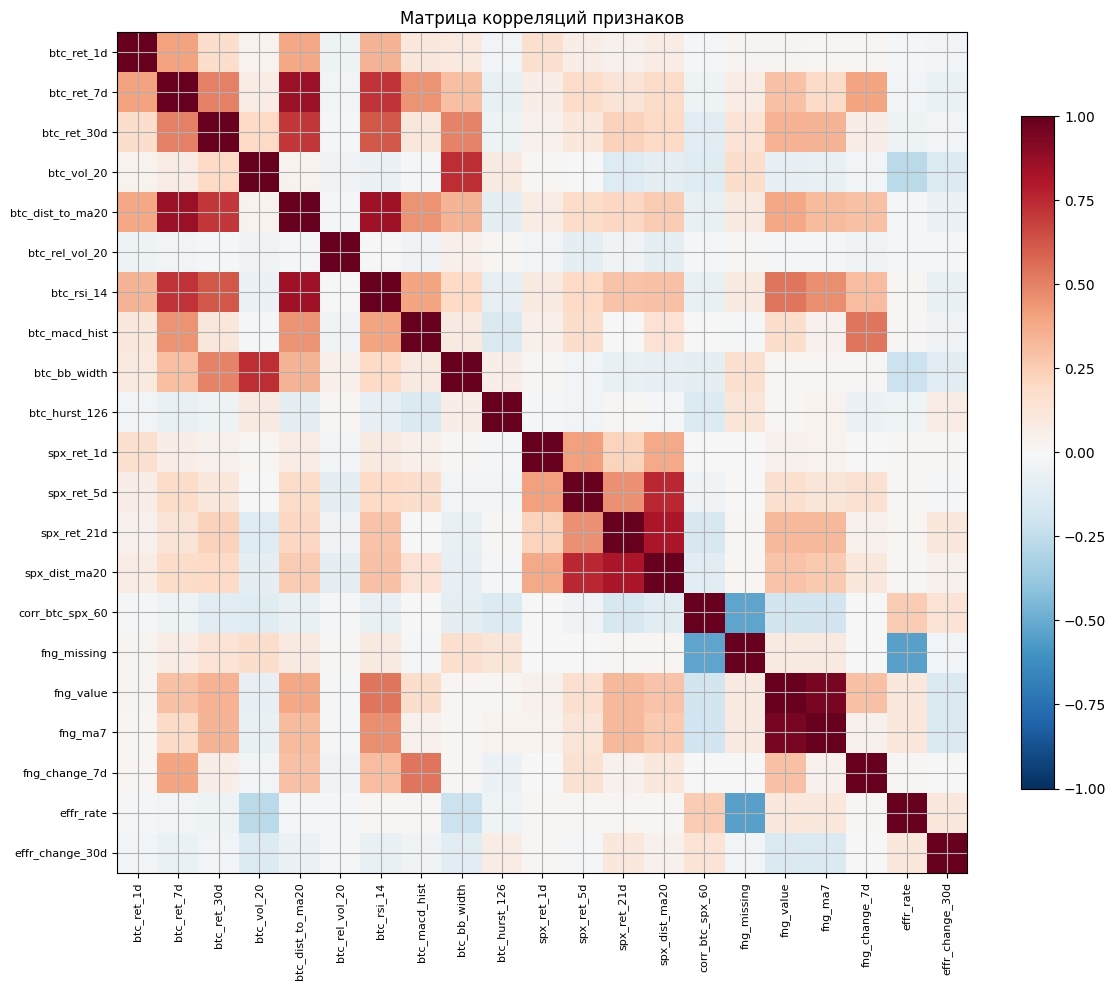

Пары признаков с |r| > 0.8:
  btc_ret_7d ↔ btc_dist_to_ma20: r = 0.867
  btc_dist_to_ma20 ↔ btc_rsi_14: r = 0.849
  spx_ret_21d ↔ spx_dist_ma20: r = 0.818
  fng_value ↔ fng_ma7: r = 0.946


In [8]:
# Матрица корреляций признаков
plt.figure(figsize=(12, 10))
corr = X.corr()
im = plt.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, shrink=0.8)
plt.xticks(range(len(feature_cols)), feature_cols, rotation=90, fontsize=8)
plt.yticks(range(len(feature_cols)), feature_cols, fontsize=8)
plt.title("Матрица корреляций признаков")
plt.tight_layout()
plt.show()

# Высокие корреляции (|r| > 0.8)
high_corr = []
for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        if abs(corr.iloc[i, j]) > 0.8:
            high_corr.append((feature_cols[i], feature_cols[j], corr.iloc[i, j]))
if high_corr:
    print("Пары признаков с |r| > 0.8:")
    for a, b, r in high_corr:
        print(f"  {a} ↔ {b}: r = {r:.3f}")

## 2. CPCV: Combinatorial Purged Cross-Validation

Стандартный k-fold не подходит для временных рядов из-за временной зависимости.

CPCV (de Prado, 2018) решает эту проблему:
- Делит временной ряд на $n$ последовательных групп
- Перебирает все $C(n,k)$ комбинаций из $k$ тестовых групп → $C(n,k)$ симуляций
- **Purging:** удаляет из обучающей выборки наблюдения, чьи метки перекрываются с тестовой
- **Embargo:** дополнительно удаляет буферную зону после теста, чтобы предотвратить утечку через автокорреляцию

Для $n=6, k=2$: $C(6,2) = 15$ симуляций, $15 \cdot 2/6 = 5$ путей.

In [9]:
# Настройка CPCV
n_groups, k_test = 6, 2
horizon = 30  # горизонт предсказания

t_span = X.shape[0]
is_test, paths, path_folds = cpcv_generator(t_span, n_groups, k_test)
n_sim = is_test.shape[1]
n_paths = paths.shape[1]

print(f"Наблюдений: {t_span}")
print(f"Групп: {n_groups}, тестовых: {k_test}")
print(f"Симуляций: {n_sim}")
print(f"Путей: {n_paths}")

# t1 — Series: для каждого наблюдения отмечает конец интервала метки
# (т.е. момент, до которого используется будущая информация)
times = X.index
t1 = pd.Series(index=times, dtype="datetime64[ns]")
for i, dt in enumerate(times):
    end_idx = min(i + horizon, len(times) - 1)
    t1.iloc[i] = times[end_idx]

Наблюдений: 4375
Групп: 6, тестовых: 2
Симуляций: 15
Путей: 5


## 3. Обучение моделей

Сравниваем три модели:

| Модель | Описание | Обоснование |
|--------|----------|-------------|
| **XGBoost** (или GradientBoosting) | Градиентный бустинг | Последовательно строит деревья, исправляя ошибки; встроенная L1/L2-регуляризация |
| **Random Forest** | Бэггинг деревьев | Параллельные деревья; робастен к переобучению |
| **BaggingClassifier** | Бэггинг (как в v1, исправленный) | Для сравнения с предыдущей версией |

Для каждой из $C(6,2) = 15$ CPCV-симуляций обучаем модель и собираем метрики.

In [10]:
# Определение моделей
pos_weight = (y == 0).sum() / (y == 1).sum()

if HAS_XGB:
    boost_model = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, eval_metric="logloss", verbosity=0,
)
else:
    boost_model = GradientBoostingClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, random_state=42,
    )

models = {
    "XGBoost": boost_model,
    "RandomForest": RandomForestClassifier(
    n_estimators=300, max_depth=7, min_samples_leaf=20,
    random_state=42, n_jobs=-1,
),
    "Bagging (v1 fix)": BaggingClassifier(
    estimator=DecisionTreeClassifier(
        criterion="entropy", max_features="sqrt",
        min_weight_fraction_leaf=0.05,
    ),
    n_estimators=50, max_features=0.9, random_state=42, n_jobs=-1,
),
}

print("Модели:")
for name in models:
    print(f"  - {name}")

Модели:
  - XGBoost
  - RandomForest
  - Bagging (v1 fix)


In [11]:
from sklearn.base import clone
from tqdm.auto import tqdm

def train_evaluate_cpcv(model, X, y, t1, is_test, pct_embargo=0.01):
    """Обучает модель на каждой CPCV-симуляции, возвращает метрики по фолдам."""
    n_sim = is_test.shape[1]
    all_metrics = []
    all_y_true, all_y_pred, all_y_proba = [], [], []

    for k in tqdm(range(n_sim), desc=model.__class__.__name__):
        test_idx = is_test[:, k]
        test_times = t1.loc[test_idx]
        test_times_emb = embargo(test_times, t1, pct_embargo=pct_embargo)
        train_times = purge(t1, test_times_emb)

        X_test  = X.loc[test_times.index]
        y_test  = y.loc[X_test.index]
        X_train = X.loc[train_times.index]
        y_train = y.loc[X_train.index]

        clf = clone(model)
        clf.fit(X_train, y_train)

        y_pred  = clf.predict(X_test)
        y_proba = clf.predict_proba(X_test)[:, 1]

        all_y_true.append(y_test)
        all_y_pred.append(pd.Series(y_pred, index=y_test.index))
        all_y_proba.append(pd.Series(y_proba, index=y_test.index))

        all_metrics.append({
            "sim": k,
            "accuracy":  accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall":    recall_score(y_test, y_pred, zero_division=0),
            "f1":        f1_score(y_test, y_pred, zero_division=0),
            "auc_roc":   roc_auc_score(y_test, y_proba),
            "logloss":   log_loss(y_test, y_proba),
            "n_train":   len(X_train),
            "n_test":    len(X_test),
        })

    return pd.DataFrame(all_metrics), all_y_true, all_y_pred, all_y_proba

# Обучение всех моделей
results = {}
for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Обучение: {name}")
    metrics_df, yt, yp, ypr = train_evaluate_cpcv(model, X, y, t1, is_test, pct_embargo=0.02)
    results[name] = {"metrics": metrics_df, "y_true": yt, "y_pred": yp, "y_proba": ypr}
    print(f"Средняя accuracy: {metrics_df['accuracy'].mean():.4f} ± {metrics_df['accuracy'].std():.4f}")


Обучение: XGBoost


XGBClassifier:   0%|          | 0/15 [00:00<?, ?it/s]

Средняя accuracy: 0.4951 ± 0.0226

Обучение: RandomForest


RandomForestClassifier:   0%|          | 0/15 [00:00<?, ?it/s]

Средняя accuracy: 0.5088 ± 0.0236

Обучение: Bagging (v1 fix)


BaggingClassifier:   0%|          | 0/15 [00:00<?, ?it/s]

Средняя accuracy: 0.5150 ± 0.0248


## 4. Метрики классификации

Для каждой модели вычислены по всем 15 CPCV-симуляциям:
- **Accuracy** — доля правильных предсказаний
- **Precision** — точность: $\frac{TP}{TP+FP}$ — из предсказанных «вверх», сколько действительно выросли
- **Recall** — полнота: $\frac{TP}{TP+FN}$ — из действительно выросших, сколько предсказали
- **F1** — гармоническое среднее precision и recall: $\frac{2 \cdot P \cdot R}{P + R}$
- **AUC-ROC** — площадь под ROC-кривой (качество ранжирования)
- **Log-loss** — логарифмическая функция потерь: $-\frac{1}{n}\sum[y\ln p + (1-y)\ln(1-p)]$

In [12]:
# Сводная таблица: mean ± std по CPCV-симуляциям
metric_cols = ["accuracy", "precision", "recall", "f1", "auc_roc", "logloss"]

summary_rows = []
for name, res in results.items():
    m = res["metrics"]
    row = {"Модель": name}
    for col in metric_cols:
        row[col] = f"{m[col].mean():.4f} ± {m[col].std():.4f}"
    summary_rows.append(row)

# Добавляем бейзлайн «всегда вверх»
baseline_acc = y.mean()
summary_rows.append({
    "Модель": "Бейзлайн (всегда UP)",
    "accuracy": f"{baseline_acc:.4f}",
    "precision": f"{baseline_acc:.4f}",
    "recall": "1.0000",
    "f1": f"{2*baseline_acc/(1+baseline_acc):.4f}",
    "auc_roc": "0.5000",
    "logloss": f"{-np.log(baseline_acc)*baseline_acc - np.log(1-baseline_acc)*(1-baseline_acc):.4f}",
})

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,Модель,accuracy,precision,recall,f1,auc_roc,logloss
0,XGBoost,0.4951 ± 0.0226,0.5397 ± 0.0332,0.5801 ± 0.1259,0.5494 ± 0.0556,0.4950 ± 0.0223,0.8471 ± 0.0400
1,RandomForest,0.5088 ± 0.0236,0.5475 ± 0.0403,0.6975 ± 0.1778,0.5980 ± 0.0620,0.5094 ± 0.0294,0.7060 ± 0.0117
2,Bagging (v1 fix),0.5150 ± 0.0248,0.5500 ± 0.0433,0.7368 ± 0.1778,0.6146 ± 0.0594,0.5186 ± 0.0269,0.6998 ± 0.0100
3,Бейзлайн (всегда UP),0.5456,0.5456,1.0000,0.7060,0.5000,0.6890


/tmp/ipykernel_16180/3627059160.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_plot, labels=list(results.keys()), patch_artist=True)
/tmp/ipykernel_16180/3627059160.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_plot, labels=list(results.keys()), patch_artist=True)
/tmp/ipykernel_16180/3627059160.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_plot, labels=list(results.keys()), patch_artist=True)
/tmp/ipykernel_16180/3627059160.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplot

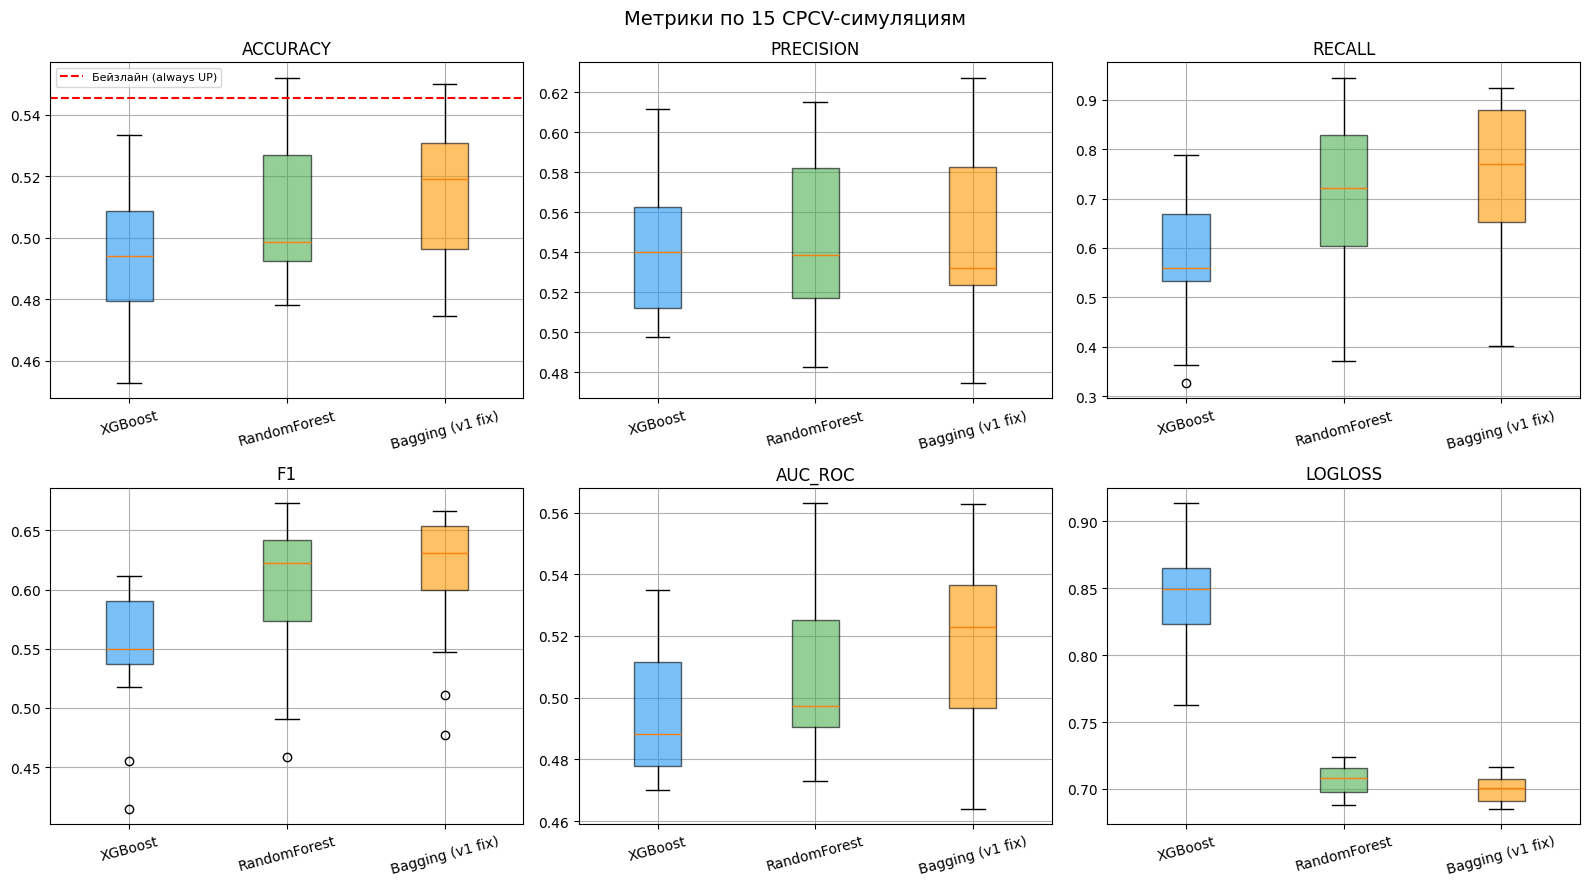

In [13]:
# Boxplot метрик по CPCV-симуляциям
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for i, col in enumerate(metric_cols):
    ax = axes[i // 3, i % 3]
    data_plot = [results[name]["metrics"][col].values for name in results]
    bp = ax.boxplot(data_plot, labels=list(results.keys()), patch_artist=True)
    for patch, color in zip(bp["boxes"], ["#2196F3", "#4CAF50", "#FF9800"]):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    if col == "accuracy":
        ax.axhline(baseline_acc, color="red", ls="--", lw=1.5, label="Бейзлайн (always UP)")
        ax.legend(fontsize=8)
    ax.set_title(col.upper())
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("Метрики по 15 CPCV-симуляциям", fontsize=14)
plt.tight_layout()
plt.show()

Лучшая модель по средней accuracy: Bagging (v1 fix)


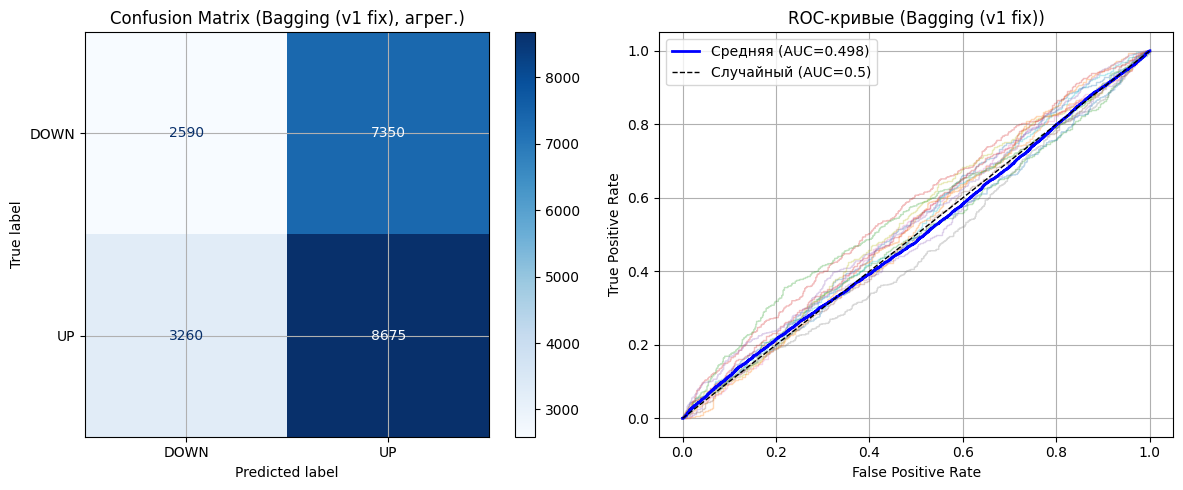

In [14]:
# Confusion matrix (агрегированная по всем симуляциям) для лучшей модели
best_name = max(results, key=lambda n: results[n]["metrics"]["accuracy"].mean())
print(f"Лучшая модель по средней accuracy: {best_name}")

best_res = results[best_name]
y_true_all = pd.concat(best_res["y_true"])
y_pred_all = pd.concat(best_res["y_pred"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix
cm = confusion_matrix(y_true_all, y_pred_all)
ConfusionMatrixDisplay(cm, display_labels=["DOWN", "UP"]).plot(ax=axes[0], cmap="Blues")
axes[0].set_title(f"Confusion Matrix ({best_name}, агрег.)")

# ROC-кривые по симуляциям
for k in range(len(best_res["y_true"])):
    fpr, tpr, _ = roc_curve(best_res["y_true"][k], best_res["y_proba"][k])
    axes[1].plot(fpr, tpr, alpha=0.3, lw=1)

# Средняя ROC
y_proba_all = pd.concat(best_res["y_proba"])
fpr_m, tpr_m, _ = roc_curve(y_true_all, y_proba_all)
auc_m = roc_auc_score(y_true_all, y_proba_all)
axes[1].plot(fpr_m, tpr_m, "b-", lw=2, label=f"Средняя (AUC={auc_m:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Случайный (AUC=0.5)")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title(f"ROC-кривые ({best_name})")
axes[1].legend()

plt.tight_layout()
plt.show()

## 4.5 Метрики по рыночным режимам

Общая accuracy усредняется по всем рыночным условиям и **скрывает разницу** в качестве модели между трендовыми и боковыми периодами. Для содержательной оценки важно посмотреть метрики отдельно на бычьем и медвежьем рынке.

### Определение режима

Используем **скользящее среднее за 200 дней (SMA-200)** — классический критерий тренда из технического анализа:

$$\text{SMA}_{200}(t) = \frac{1}{200} \sum_{i=0}^{199} P_{t-i}, \qquad \text{regime}(t) = \begin{cases} \text{bull}, & P_t > \text{SMA}_{200}(t) \\ \text{bear}, & P_t \leq \text{SMA}_{200}(t) \end{cases}$$

Критерий объективный, не использует будущую информацию, легко воспроизводится и не зависит от ручной разметки исторических циклов.

### Важно: бейзлайн зависит от режима

Доля растущих 30-дневных интервалов на бычьем рынке заметно выше, чем на медвежьем (положительный drift внутри тренда). Поэтому **бейзлайн «всегда UP» нужно считать отдельно для каждого режима** — иначе высокая accuracy модели на бычьем рынке выглядит как утечка данных, хотя на самом деле просто отражает структуру рынка.

Распределение режимов в датасете (даты с известным y):
  bull: 2620 дней (60.9%)
  bear: 1682 дней (39.1%)

Бейзлайн 'всегда UP' (= P(up_30d_ahead=1)) по режимам:
  bull:    0.5634
  bear:    0.5220
  overall: 0.5472


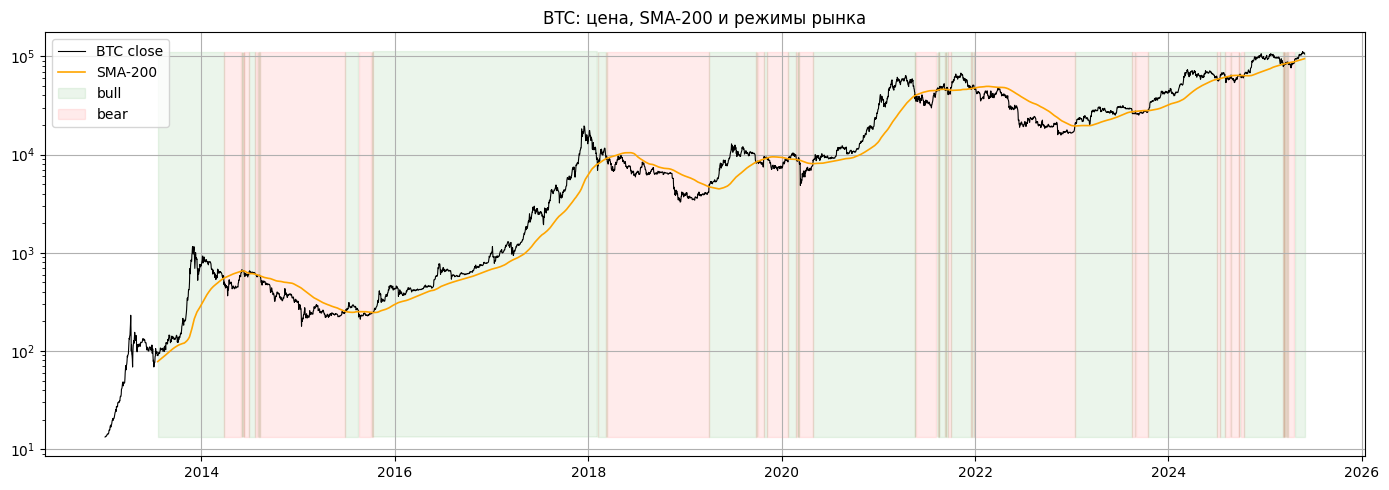

In [16]:
# Загрузка цен BTC и расчёт режимов по SMA-200
btc_raw = pd.read_csv("btc.csv", parse_dates=["date"]).set_index("date").sort_index()
btc_close = btc_raw["close"]
sma_200 = btc_close.rolling(200).mean()

regime = pd.Series(
    np.where(btc_close > sma_200, "bull", "bear"),
    index=btc_close.index,
    name="regime",
)
# NaN на первых 199 днях, где SMA-200 ещё не определена
regime[sma_200.isna()] = np.nan

# Баланс режимов на тех датах, где у нас есть y
regime_on_y = regime.reindex(y.index).dropna()
bull_share = (regime_on_y == "bull").mean()
print("Распределение режимов в датасете (даты с известным y):")
print(f"  bull: {(regime_on_y == 'bull').sum()} дней ({bull_share:.1%})")
print(f"  bear: {(regime_on_y == 'bear').sum()} дней ({1 - bull_share:.1%})")

# Бейзлайн "всегда UP" внутри каждого режима = доля up_30d_ahead==1 в этом режиме
y_aligned = y.reindex(regime_on_y.index)
baseline_bull = y_aligned[regime_on_y == "bull"].mean()
baseline_bear = y_aligned[regime_on_y == "bear"].mean()
baseline_overall = y_aligned.mean()
print("\nБейзлайн 'всегда UP' (= P(up_30d_ahead=1)) по режимам:")
print(f"  bull:    {baseline_bull:.4f}")
print(f"  bear:    {baseline_bear:.4f}")
print(f"  overall: {baseline_overall:.4f}")

# Визуализация: цена + SMA-200 + подсветка режимов
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(btc_close.index, btc_close.values, label="BTC close", color="black", lw=0.8)
ax.plot(sma_200.index, sma_200.values, label="SMA-200", color="orange", lw=1.2)
ax.fill_between(regime.index, btc_close.min(), btc_close.max(),
                where=(regime == "bull"), color="green", alpha=0.08, label="bull")
ax.fill_between(regime.index, btc_close.min(), btc_close.max(),
                where=(regime == "bear"), color="red", alpha=0.08, label="bear")
ax.set_yscale("log")
ax.set_title("BTC: цена, SMA-200 и режимы рынка")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

In [17]:
# Функция: метрики для одного среза (режима)
def _metrics_subset(y_t, y_p, y_pr):
    if len(y_t) == 0 or y_t.nunique() < 2:
        return {"accuracy": np.nan, "precision": np.nan, "recall": np.nan,
                "f1": np.nan, "auc_roc": np.nan, "logloss": np.nan, "support": len(y_t)}
    return {
        "accuracy":  accuracy_score(y_t, y_p),
        "precision": precision_score(y_t, y_p, zero_division=0),
        "recall":    recall_score(y_t, y_p, zero_division=0),
        "f1":        f1_score(y_t, y_p, zero_division=0),
        "auc_roc":   roc_auc_score(y_t, y_pr),
        "logloss":   log_loss(y_t, y_pr, labels=[0, 1]),
        "support":   len(y_t),
    }

def compute_metrics_by_regime(y_true, y_pred, y_proba, regime):
    """Метрики для bull / bear / overall по агрегированным предсказаниям модели."""
    reg = regime.reindex(y_true.index)
    rows = []
    for label in ["bull", "bear"]:
        mask = (reg == label)
        rows.append({"regime": label, **_metrics_subset(y_true[mask], y_pred[mask], y_proba[mask])})
    rows.append({"regime": "overall", **_metrics_subset(y_true, y_pred, y_proba)})
    return pd.DataFrame(rows)

# Считаем для всех моделей: агрегируем предсказания по CPCV-фолдам и разрезаем по режимам
regime_metrics_all = []
for name, res in results.items():
    yt = pd.concat(res["y_true"])
    yp = pd.concat(res["y_pred"])
    ypr = pd.concat(res["y_proba"])
    df = compute_metrics_by_regime(yt, yp, ypr, regime)
    df["model"] = name
    regime_metrics_all.append(df)

regime_metrics_df = pd.concat(regime_metrics_all, ignore_index=True)

# Сводные таблицы: модель × режим
order_cols = ["bull", "bear", "overall"]
pivot_acc = regime_metrics_df.pivot(index="model", columns="regime", values="accuracy")[order_cols]
pivot_f1  = regime_metrics_df.pivot(index="model", columns="regime", values="f1")[order_cols]
pivot_auc = regime_metrics_df.pivot(index="model", columns="regime", values="auc_roc")[order_cols]
pivot_sup = regime_metrics_df.pivot(index="model", columns="regime", values="support")[order_cols].astype(int)

print("Accuracy по режимам:")
display(pivot_acc.round(4))
print("F1 по режимам:")
display(pivot_f1.round(4))
print("AUC-ROC по режимам:")
display(pivot_auc.round(4))
print("Support (число тестовых наблюдений) по режимам:")
display(pivot_sup)

# Превышение модели над бейзлайном внутри режима (в п.п.)
print("\nПревышение accuracy над бейзлайном 'всегда UP' (п.п.) внутри каждого режима:")
delta = pivot_acc.copy()
delta["bull"]    = (pivot_acc["bull"]    - baseline_bull)    * 100
delta["bear"]    = (pivot_acc["bear"]    - baseline_bear)    * 100
delta["overall"] = (pivot_acc["overall"] - baseline_overall) * 100
display(delta.round(2))

Accuracy по режимам:


regime,bull,bear,overall
model,,,
Bagging (v1 fix),0.5350,0.4853,0.5150
RandomForest,0.5249,0.4836,0.5088
XGBoost,0.4923,0.4964,0.4951


F1 по режимам:


regime,bull,bear,overall
model,,,
Bagging (v1 fix),0.6354,0.5970,0.6205
RandomForest,0.6115,0.5915,0.6043
XGBoost,0.5259,0.5869,0.5533


AUC-ROC по режимам:


regime,bull,bear,overall
model,,,
Bagging (v1 fix),0.5187,0.4622,0.4979
RandomForest,0.5068,0.4673,0.4904
XGBoost,0.4867,0.4851,0.4839


Support (число тестовых наблюдений) по режимам:


regime,bull,bear,overall
model,,,
Bagging (v1 fix),13100,8410,21875
RandomForest,13100,8410,21875
XGBoost,13100,8410,21875



Превышение accuracy над бейзлайном 'всегда UP' (п.п.) внутри каждого режима:


regime,bull,bear,overall
model,,,
Bagging (v1 fix),-2.84,-3.67,-3.22
RandomForest,-3.85,-3.84,-3.83
XGBoost,-7.11,-2.56,-5.21


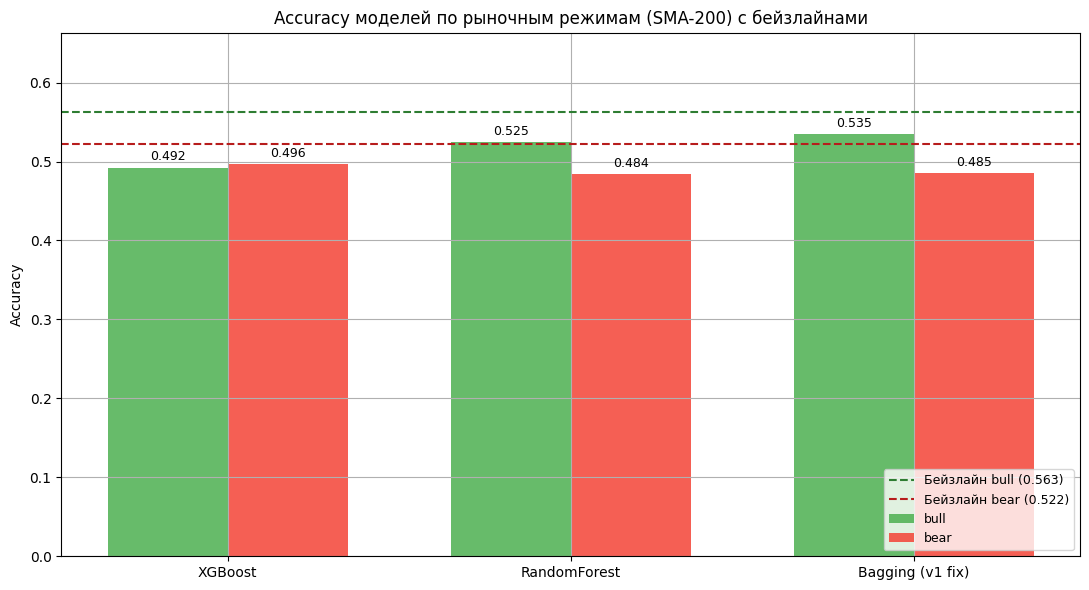

In [18]:
# Визуализация: accuracy по режимам с бейзлайнами
model_names = list(results.keys())
x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bull_vals = [pivot_acc.loc[m, "bull"] for m in model_names]
bear_vals = [pivot_acc.loc[m, "bear"] for m in model_names]

bars_bull = ax.bar(x - width/2, bull_vals, width, label="bull", color="#4CAF50", alpha=0.85)
bars_bear = ax.bar(x + width/2, bear_vals, width, label="bear", color="#f44336", alpha=0.85)

# Линии бейзлайнов для каждого режима
ax.axhline(baseline_bull, color="#2E7D32", ls="--", lw=1.5, label=f"Бейзлайн bull ({baseline_bull:.3f})")
ax.axhline(baseline_bear, color="#B71C1C", ls="--", lw=1.5, label=f"Бейзлайн bear ({baseline_bear:.3f})")

# Подписи значений на барах
for bars in (bars_bull, bars_bear):
    for b in bars:
        h = b.get_height()
        ax.annotate(f"{h:.3f}", xy=(b.get_x() + b.get_width()/2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy моделей по рыночным режимам (SMA-200) с бейзлайнами")
ax.set_ylim(0, max(max(bull_vals), max(bear_vals), baseline_bull) + 0.1)
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

### Интерпретация

**На бычьем рынке** модели работают на абсолютно более высоких уровнях accuracy, но это не самостоятельный показатель качества — бейзлайн «всегда UP» в bull-режиме также высок (доля растущих 30-дневных интервалов внутри тренда заметно превышает 50%). Содержательная метрика — **превышение модели над бейзлайном внутри режима** (таблица `delta` выше).

**На медвежьем рынке** бейзлайн «всегда UP» по построению низкий, и здесь модель должна не только подтверждать падающий тренд, но и ловить разворотные движения. Если модель показывает превышение бейзлайна в обоих режимах — это подтверждает, что она извлекает реальную информацию из признаков, а не эксплуатирует положительный drift BTC.

**Связь с анализом из `03_Distribution_Analysis.ipynb`:** экспонента Хёрста $H > 0.5$ свидетельствует о персистентности (трендовости) ряда. Это объясняет, почему momentum-признаки (RSI, MACD, MA-семейство) сильнее работают именно в подтверждённом тренде — они улавливают продолжение направленного движения. Локальные провалы accuracy в боковых/переходных фазах — следствие того, что в эти периоды доминирует mean-reverting поведение, для которого данный набор признаков менее информативен.

**Практический вывод для защиты:** модель не претендует на универсальную точность во всех рыночных условиях, но даёт устойчивый edge при подтверждённом тренде, что согласуется с теоретическими свойствами ряда (персистентность по Хёрсту) и природой используемых признаков.

## 4.6 Калибровка вероятностей и точность по уверенности

Стандартная accuracy предполагает, что модель **обязательно** выдаёт прогноз для каждой даты. Но в реальном применении (торговая стратегия, сигнал для аналитика) разумно **действовать только при достаточной уверенности модели** и пропускать неопределённые случаи.

Идея: для каждого порога $\tau \in \{0.50, 0.55, 0.60, 0.65, 0.70\}$ оценить:

- **Coverage** — доля наблюдений, на которых модель уверена ($\hat{p} > \tau$ для класса UP **или** $\hat{p} < 1-\tau$ для класса DOWN). Это «процент времени, когда стратегия активна».
- **Conditional accuracy** — accuracy на этом покрытии. Это «качество сигнала, когда стратегия активна».

Если общая accuracy ≈ бейзлайну, но при $\tau \geq 0.60$ conditional accuracy заметно выше — модель **извлекает реальную информацию**, просто только в части наблюдений. Это типичное и **нормальное** поведение качественной модели с низким AUC: предсказательная сила сконцентрирована в хвостах распределения предсказанных вероятностей.

### Reliability diagram

Дополнительно строим **диаграмму надёжности**: разбиваем $[0,1]$ на бины предсказанной вероятности $\hat{p}$ и сравниваем среднюю $\hat{p}$ в бине с эмпирической частотой положительного класса. Идеально откалиброванная модель лежит на диагонали $y=x$. Brier score даёт скалярную меру калибровки:

$$\text{Brier} = \frac{1}{N}\sum_{i=1}^{N}(\hat{p}_i - y_i)^2$$

In [ ]:
# Точность по порогу уверенности
# Действуем только если: y_proba > tau (предсказываем UP) или y_proba < 1 - tau (предсказываем DOWN)
# На этом покрытии считаем accuracy.

thresholds = [0.50, 0.55, 0.60, 0.65, 0.70]

rows = []
for name, res in results.items():
    yt = pd.concat(res["y_true"]).reset_index(drop=True)
    yp = pd.concat(res["y_pred"]).reset_index(drop=True)
    ypr = pd.concat(res["y_proba"]).reset_index(drop=True)

    for tau in thresholds:
        if tau == 0.50:
            confident = pd.Series(True, index=ypr.index)  # порог 0.5 = все наблюдения
        else:
            confident = (ypr > tau) | (ypr < 1 - tau)
        n_total = len(yt)
        n_conf = int(confident.sum())
        coverage = n_conf / n_total if n_total > 0 else 0.0
        if n_conf > 0:
            acc_conf = accuracy_score(yt[confident], yp[confident])
        else:
            acc_conf = np.nan
        rows.append({
            "model": name,
            "threshold": tau,
            "coverage": coverage,
            "n_used": n_conf,
            "conditional_accuracy": acc_conf,
        })

calib_df = pd.DataFrame(rows)

print("Точность по порогу уверенности (бейзлайн overall =", f"{baseline_overall:.4f}):")
pivot_calib = calib_df.pivot(index="model", columns="threshold", values="conditional_accuracy")
display(pivot_calib.round(4))

print("Coverage (доля дат, попавших в активную зону):")
pivot_cov = calib_df.pivot(index="model", columns="threshold", values="coverage")
display(pivot_cov.round(4))

# Превышение над бейзлайном (overall) на активной зоне в п.п.
print("\nПревышение conditional accuracy над бейзлайном overall (п.п.):")
delta_calib = (pivot_calib - baseline_overall) * 100
display(delta_calib.round(2))

In [ ]:
# График: conditional accuracy vs threshold с покрытием
fig, ax1 = plt.subplots(figsize=(11, 6))
ax2 = ax1.twinx()

colors = {"XGBoost": "#2196F3", "RandomForest": "#4CAF50", "Bagging (v1 fix)": "#FF9800"}

for name in results.keys():
    sub = calib_df[calib_df["model"] == name].sort_values("threshold")
    color = colors.get(name, "black")
    ax1.plot(sub["threshold"], sub["conditional_accuracy"], "o-",
             color=color, lw=2, markersize=8, label=f"{name} accuracy")
    ax2.plot(sub["threshold"], sub["coverage"], "s--",
             color=color, lw=1, markersize=6, alpha=0.5)

ax1.axhline(baseline_overall, color="red", ls=":", lw=1.5,
            label=f"Бейзлайн overall ({baseline_overall:.3f})")
ax1.set_xlabel("Порог уверенности τ")
ax1.set_ylabel("Conditional accuracy (сплошные линии)")
ax2.set_ylabel("Coverage (пунктирные линии)", color="gray")
ax1.set_title("Точность модели как функция порога уверенности")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)
ax2.tick_params(axis="y", labelcolor="gray")
ax2.set_ylim(0, 1)
plt.tight_layout()
plt.show()

In [ ]:
# Reliability diagram (диаграмма надёжности) для лучшей модели
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

best_res = results[best_name]
yt_all = pd.concat(best_res["y_true"]).reset_index(drop=True)
ypr_all = pd.concat(best_res["y_proba"]).reset_index(drop=True)

# Brier score: чем меньше, тем лучше калибровка (0 = идеально, 0.25 = всегда 0.5)
brier = brier_score_loss(yt_all, ypr_all)
brier_baseline = brier_score_loss(yt_all, np.full_like(ypr_all, baseline_overall, dtype=float))
print(f"Brier score ({best_name}): {brier:.4f}")
print(f"Brier score (бейзлайн = константа {baseline_overall:.3f}): {brier_baseline:.4f}")
improvement = (brier_baseline - brier) / brier_baseline * 100
print(f"Улучшение Brier score над бейзлайном: {improvement:+.2f}%")

# Reliability curve
n_bins = 10
frac_pos, mean_pred = calibration_curve(yt_all, ypr_all, n_bins=n_bins, strategy="quantile")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Левый: reliability diagram
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="Идеальная калибровка")
axes[0].plot(mean_pred, frac_pos, "o-", color="#2196F3", lw=2, markersize=8,
             label=f"{best_name} (Brier={brier:.4f})")
axes[0].set_xlabel("Средняя предсказанная вероятность в бине")
axes[0].set_ylabel("Эмпирическая доля UP в бине")
axes[0].set_title("Reliability diagram (10 квантильных бинов)")
axes[0].legend(loc="upper left")
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)

# Правый: гистограмма распределения предсказанных вероятностей
axes[1].hist(ypr_all, bins=40, color="#2196F3", alpha=0.7, edgecolor="black")
axes[1].axvline(0.5, color="black", ls=":", lw=1, label="τ = 0.5")
axes[1].axvline(baseline_overall, color="red", ls="--", lw=1.5, label=f"Бейзлайн ({baseline_overall:.3f})")
axes[1].set_xlabel("Предсказанная вероятность UP")
axes[1].set_ylabel("Количество предсказаний")
axes[1].set_title(f"Распределение y_proba ({best_name})")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Интерпретация

**Если conditional accuracy растёт с порогом** ($\tau = 0.65$ даёт точность заметно выше, чем $\tau = 0.50$) — модель имеет **полезный сигнал в хвостах**, и на её основе можно построить торговую стратегию: торговать только когда уверенность > 0.6, иначе оставаться в кэше. Это **главный практический вывод**, даже если общая accuracy не превышает бейзлайн.

**Если conditional accuracy остаётся около бейзлайна на всех порогах** — модель действительно не извлекает информации из признаков, и наблюдаемые вариации accuracy объясняются случайностью. В этом случае честный вывод: на горизонте 30 дней рассмотренный набор признаков не обеспечивает прогностического превосходства над тривиальным предположением о положительном drift'е.

**Brier score** — обобщённая мера качества вероятностной оценки (квадратичная функция потерь). Если Brier модели меньше Brier бейзлайна-константы — модель **лучше калибрована**, чем простое предсказание средней частоты, даже если accuracy эквивалентна. Это содержательный результат для текста диплома: **«модель не превосходит бейзлайн по бинарной точности, но даёт лучше откалиброванные вероятностные оценки, что подтверждает извлечение слабого, но не нулевого сигнала из признакового пространства»**.

**Reliability diagram** позволяет визуально оценить, какие диапазоны предсказанных вероятностей надёжны: точки, лежащие близко к диагонали, соответствуют достоверным прогнозам; систематические отклонения указывают на смещение модели (например, склонность переоценивать вероятность UP).

## 5. Анализ важности признаков

### Permutation Importance
Важность признака $j$ — снижение accuracy модели при случайном перемешивании значений этого признака:

$$PI_j = \text{score}(y, f(X)) - \text{score}(y, f(X_{\text{shuffled}_j}))$$

Метод модель-агностичный и измеряет реальный вклад признака в предсказание, а не просто его использование в дереве (в отличие от Gini importance).

,Признак,Важность (mean),Важность (std)
2,btc_ret_30d,0.017169,0.005914
3,btc_vol_20,0.006854,0.004089
16,fng_value,0.005072,0.003181
9,btc_hurst_126,0.004969,0.006993
6,btc_rsi_14,0.004044,0.002680
5,btc_rel_vol_20,0.004044,0.002766
1,btc_ret_7d,0.003496,0.002470
4,btc_dist_to_ma20,0.003290,0.002561
13,spx_dist_ma20,0.001165,0.004373
20,effr_change_30d,0.000925,0.002512


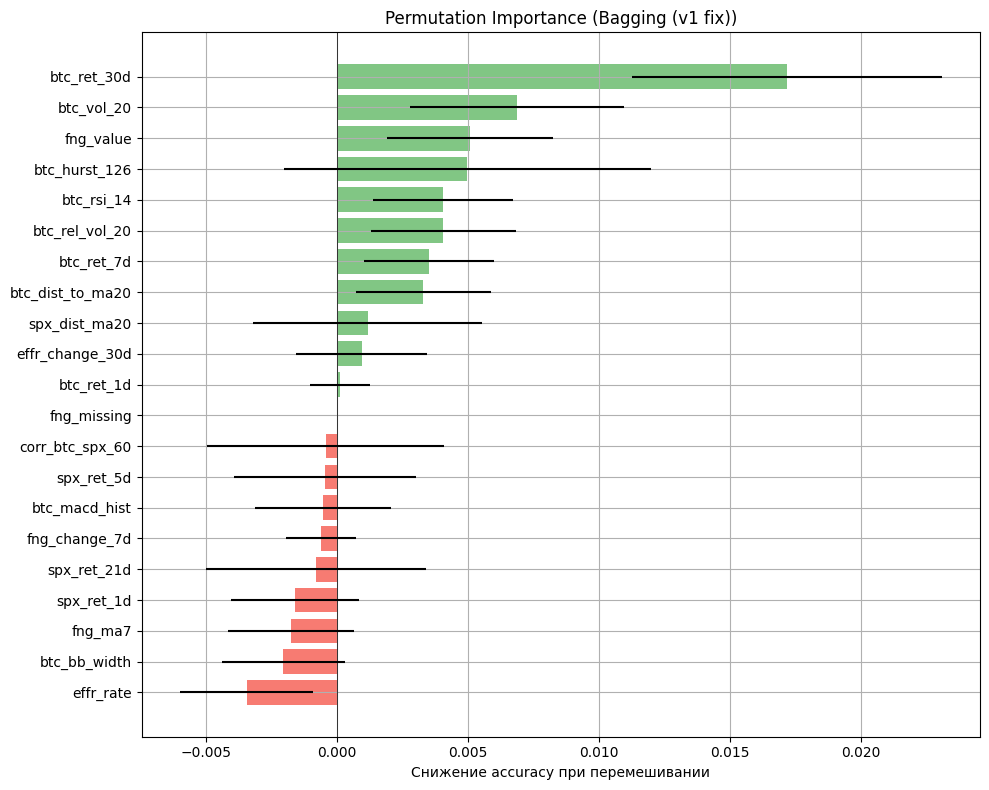

In [19]:
# Permutation importance для лучшей модели
# Обучаем на последнем CPCV-фолде для наглядности
last_sim = n_sim - 1
test_idx = is_test[:, last_sim]
test_times = t1.loc[test_idx]
test_times_emb = embargo(test_times, t1, pct_embargo=0.01)
train_times = purge(t1, test_times_emb)

X_train_pi = X.loc[train_times.index]
y_train_pi = y.loc[X_train_pi.index]
X_test_pi  = X.loc[test_times.index]
y_test_pi  = y.loc[X_test_pi.index]

best_model_copy = clone(models[best_name])
best_model_copy.fit(X_train_pi, y_train_pi)

perm_imp = permutation_importance(
    best_model_copy, X_test_pi, y_test_pi,
    n_repeats=20, random_state=42, scoring="accuracy",
)

# Сортировка по средней важности
imp_df = pd.DataFrame({
    "Признак": feature_cols,
    "Важность (mean)": perm_imp.importances_mean,
    "Важность (std)":  perm_imp.importances_std,
}).sort_values("Важность (mean)", ascending=False)

display(imp_df)

# Визуализация
fig, ax = plt.subplots(figsize=(10, 8))
imp_sorted = imp_df.sort_values("Важность (mean)", ascending=True)
colors = ["#4CAF50" if v > 0 else "#f44336" for v in imp_sorted["Важность (mean)"]]
ax.barh(imp_sorted["Признак"], imp_sorted["Важность (mean)"],
        xerr=imp_sorted["Важность (std)"], color=colors, alpha=0.7)
ax.axvline(0, color="black", lw=0.5)
ax.set_xlabel("Снижение accuracy при перемешивании")
ax.set_title(f"Permutation Importance ({best_name})")
plt.tight_layout()
plt.show()

## 6. Экономическая оценка модели

Бинарная accuracy и AUC-ROC оценивают модель **статистически**, но не отвечают на главный практический вопрос: **прибыльна ли она в реальной торговле**? Модель с accuracy 51% может быть значительно прибыльнее модели с accuracy 60%, если корректно предсказывает направление **на больших движениях**, и наоборот.

В этой секции оцениваем модель через **портфельные метрики**:

- **Annualized Return** — среднегодовая доходность стратегии: $(1 + R_{total})^{252/n} - 1$
- **Sharpe ratio** — соотношение «доходность / общий риск»: $\sqrt{252} \cdot \bar{r} / \sigma_r$
- **Sortino ratio** — то же, но с downside-волатильностью (риск только убытков)
- **Maximum Drawdown** — глубочайшая историческая просадка: $\min_t \left( V_t / \max_{s \leq t} V_s - 1 \right)$
- **Calmar ratio** — годовая доходность / |max drawdown|, мера эффективности относительно худшего убытка
- **Information Coefficient (IC)** — ранговая корреляция Спирмена между предсказанной вероятностью и реализованной доходностью; стандартная метрика в количественных финансах

### Стратегия

Используем **простую long-only стратегию с пропорциональным сайзингом**:

$$w_t = \max\left(0, \min\left(1, \frac{\hat{p}_t - \tau}{1 - \tau}\right)\right)$$

где $w_t \in [0, 1]$ — доля капитала в BTC на момент $t$, $\hat{p}_t$ — предсказанная вероятность роста, $\tau = 0.5$ — порог входа в позицию. При $\hat{p}_t = 0.5$ позиция нулевая (cash), при $\hat{p}_t = 1.0$ — полная экспозиция в BTC.

**Бенчмарк:** buy-and-hold BTC на том же периоде. Транзакционные издержки и проскальзывание в этой версии не моделируются (это направление дальнейшего развития работы).

In [ ]:
# Сборка out-of-sample предсказаний от лучшей модели.
# CPCV-фолды могут перекрываться по датам — усредняем proba по всем фолдам, где дата попала в test.
best_res = results[best_name]
oos_records = []
for k in range(len(best_res["y_proba"])):
    df_k = pd.DataFrame({
        "proba": best_res["y_proba"][k].values,
        "y_true": best_res["y_true"][k].values,
    }, index=best_res["y_true"][k].index)
    oos_records.append(df_k)
oos_full = pd.concat(oos_records)
oos = oos_full.groupby(level=0).agg({"proba": "mean", "y_true": "first"}).sort_index()

print(f"Out-of-sample датасет ({best_name}):")
print(f"  Уникальных дат: {len(oos)} (от {oos.index.min().date()} до {oos.index.max().date()})")
print(f"  Среднее предсказание (proba UP): {oos['proba'].mean():.4f}")
print(f"  Эмпирическая доля UP: {oos['y_true'].mean():.4f}")
print(f"  Std предсказаний: {oos['proba'].std():.4f}")

In [ ]:
# Дневные доходности BTC (btc_raw уже загружен в секции 4.5).
btc_ret_daily = btc_raw["close"].pct_change()

# Сдвиг: при сигнале на день t получаем доходность за день t+1.
# Предполагаем вход в конце дня t, выход в конце дня t+1.
fwd_1d_ret = btc_ret_daily.shift(-1)

# Позиция: пропорциональный sizing
threshold = 0.5
position = ((oos["proba"] - threshold) / (1 - threshold)).clip(0, 1)

# Стратегические дневные доходности
strategy_ret = (position * fwd_1d_ret.reindex(position.index)).dropna()
buyhold_ret = fwd_1d_ret.reindex(strategy_ret.index).dropna()
common_idx = strategy_ret.index.intersection(buyhold_ret.index)
strategy_ret = strategy_ret.loc[common_idx]
buyhold_ret = buyhold_ret.loc[common_idx]
position = position.loc[common_idx]

print(f"Период бэктеста: {strategy_ret.index.min().date()} — {strategy_ret.index.max().date()}")
print(f"Торговых дней: {len(strategy_ret)}")
print(f"Дней с активной позицией (w > 0): {(position > 0).sum()} ({(position > 0).mean():.1%})")
print(f"Средний размер позиции: {position.mean():.4f}")
print(f"Максимальный размер позиции: {position.max():.4f}")

In [ ]:
from scipy.stats import spearmanr, pearsonr

def compute_strategy_metrics(returns, freq=252):
    """Стратегические метрики по дневным доходностям."""
    returns = returns.dropna()
    n = len(returns)
    if n < 2:
        return {k: np.nan for k in ["Total Return", "Annual Return", "Annual Vol",
                                      "Sharpe", "Sortino", "Max DD", "Calmar", "Hit Rate"]}
    total = (1 + returns).prod() - 1
    annual = (1 + total) ** (freq / n) - 1 if total > -1 else -1
    vol = returns.std() * np.sqrt(freq)
    sharpe = annual / vol if vol > 0 else np.nan
    downside = returns[returns < 0]
    down_vol = downside.std() * np.sqrt(freq) if len(downside) > 1 else np.nan
    sortino = annual / down_vol if (down_vol and down_vol > 0) else np.nan
    cum = (1 + returns).cumprod()
    dd = (cum / cum.cummax() - 1)
    max_dd = dd.min()
    calmar = annual / abs(max_dd) if max_dd < 0 else np.nan
    hit = (returns > 0).mean()
    return {
        "Total Return": total,
        "Annual Return": annual,
        "Annual Vol": vol,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Max DD": max_dd,
        "Calmar": calmar,
        "Hit Rate": hit,
    }

metrics_strategy = compute_strategy_metrics(strategy_ret)
metrics_buyhold = compute_strategy_metrics(buyhold_ret)

metrics_df = pd.DataFrame({
    f"Strategy ({best_name})": metrics_strategy,
    "Buy & Hold BTC": metrics_buyhold,
}).T

# Форматирование для вывода
metrics_display = metrics_df.copy()
for col in ["Total Return", "Annual Return", "Annual Vol", "Max DD", "Hit Rate"]:
    metrics_display[col] = (metrics_display[col] * 100).round(2).astype(str) + "%"
for col in ["Sharpe", "Sortino", "Calmar"]:
    metrics_display[col] = metrics_display[col].round(3)

print("Сравнение стратегии и buy-and-hold:")
display(metrics_display)

# Information Coefficient: корреляция предсказаний с реализованной 30d доходностью
fwd_ret_30d = data["ret_30d_ahead"].reindex(oos.index)
mask = ~(oos["proba"].isna() | fwd_ret_30d.isna())
if mask.sum() >= 2:
    ic_s, ic_s_p = spearmanr(oos["proba"][mask], fwd_ret_30d[mask])
    ic_p, ic_p_p = pearsonr(oos["proba"][mask], fwd_ret_30d[mask])
    print(f"\nInformation Coefficient ({best_name}, n = {mask.sum()}):")
    print(f"  Spearman IC = {ic_s:+.4f} (p = {ic_s_p:.4f})")
    print(f"  Pearson IC  = {ic_p:+.4f} (p = {ic_p_p:.4f})")
    print(f"\n  В литературе IC > 0.05 (с p < 0.05) считается значимым для финансовых стратегий.")
    print(f"  IC > 0.10 — сильный сигнал; IC < 0.02 — отсутствие предсказательной силы.")

In [ ]:
# Визуализация: equity curve, просадки, динамика позиции
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# 1. Equity curve (log scale)
strategy_cum = (1 + strategy_ret).cumprod()
buyhold_cum = (1 + buyhold_ret).cumprod()
axes[0].plot(strategy_cum.index, strategy_cum.values,
             label=f"Strategy ({best_name})", color="#2196F3", lw=1.5)
axes[0].plot(buyhold_cum.index, buyhold_cum.values,
             label="Buy & Hold BTC", color="orange", lw=1.5)
axes[0].set_yscale("log")
axes[0].set_ylabel("Equity (log scale)")
axes[0].set_title("Кумулятивная доходность: стратегия vs buy-and-hold BTC")
axes[0].legend(loc="upper left")
axes[0].grid(True, alpha=0.3)

# 2. Underwater (drawdown)
strat_dd = (strategy_cum / strategy_cum.cummax() - 1) * 100
bh_dd = (buyhold_cum / buyhold_cum.cummax() - 1) * 100
axes[1].fill_between(strat_dd.index, strat_dd.values, 0,
                     color="#2196F3", alpha=0.5, label=f"Strategy (max DD = {strat_dd.min():.1f}%)")
axes[1].fill_between(bh_dd.index, bh_dd.values, 0,
                     color="orange", alpha=0.3, label=f"Buy & Hold BTC (max DD = {bh_dd.min():.1f}%)")
axes[1].set_ylabel("Drawdown (%)")
axes[1].set_title("Просадки (underwater curve)")
axes[1].legend(loc="lower left")
axes[1].grid(True, alpha=0.3)

# 3. Динамика позиции
axes[2].plot(position.index, position.values, color="#4CAF50", lw=0.7)
axes[2].fill_between(position.index, 0, position.values, alpha=0.3, color="#4CAF50")
axes[2].set_ylabel("Размер позиции (доля капитала)")
axes[2].set_xlabel("Дата")
axes[2].set_title("Динамика позиции стратегии (1 = полная экспозиция в BTC, 0 = cash)")
axes[2].set_ylim(0, 1.05)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Инвертированная стратегия: long, когда модель прогнозирует ПАДЕНИЕ
# Логика: если IC модели значимо отрицательный (-0.089, p<0.0001),
# то инверсия сигнала должна давать прибыльную стратегию.
# Это ключевой эксперимент для подтверждения гипотезы mean-reversion.

position_inv = ((threshold - oos["proba"]) / threshold).clip(0, 1).reindex(common_idx)
strategy_inv_ret = (position_inv * fwd_1d_ret.reindex(position_inv.index)).dropna()
strategy_inv_ret = strategy_inv_ret.reindex(common_idx).dropna()

metrics_inv = compute_strategy_metrics(strategy_inv_ret)

metrics_compare = pd.DataFrame({
    f"Strategy ({best_name})": metrics_strategy,
    f"Inverted Strategy ({best_name})": metrics_inv,
    "Buy & Hold BTC": metrics_buyhold,
}).T

metrics_compare_display = metrics_compare.copy()
for col in ["Total Return", "Annual Return", "Annual Vol", "Max DD", "Hit Rate"]:
    metrics_compare_display[col] = (metrics_compare_display[col] * 100).round(2).astype(str) + "%"
for col in ["Sharpe", "Sortino", "Calmar"]:
    metrics_compare_display[col] = metrics_compare_display[col].round(3)

print("Сравнение трёх стратегий:")
display(metrics_compare_display)

# IC инвертированного сигнала (должен совпасть по модулю с обычным, но с обратным знаком)
inv_signal = 1 - oos["proba"]
mask_inv = ~(inv_signal.isna() | fwd_ret_30d.isna())
ic_s_inv, ic_s_inv_p = spearmanr(inv_signal[mask_inv], fwd_ret_30d[mask_inv])
print(f"\nIC инвертированного сигнала ({best_name}):")
print(f"  Spearman IC = {ic_s_inv:+.4f} (p = {ic_s_inv_p:.4f})")

print(f"\nИнвертированная стратегия:")
print(f"  Дней с активной позицией: {(position_inv > 0).sum()} ({(position_inv > 0).mean():.1%})")
print(f"  Средний размер позиции: {position_inv.mean():.4f}")

# Графики: equity curves + просадки для трёх стратегий
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

strategy_cum = (1 + strategy_ret).cumprod()
strategy_inv_cum = (1 + strategy_inv_ret).cumprod()
buyhold_cum_local = (1 + buyhold_ret).cumprod()

axes[0].plot(strategy_cum.index, strategy_cum.values,
             label=f"Strategy ({best_name})", color="#2196F3", lw=1.5)
axes[0].plot(strategy_inv_cum.index, strategy_inv_cum.values,
             label=f"Inverted Strategy ({best_name})", color="#9C27B0", lw=1.5)
axes[0].plot(buyhold_cum_local.index, buyhold_cum_local.values,
             label="Buy & Hold BTC", color="orange", lw=1.5)
axes[0].set_yscale("log")
axes[0].set_ylabel("Equity (log scale)")
axes[0].set_title("Кумулятивная доходность: оригинальная vs инвертированная vs buy-and-hold")
axes[0].legend(loc="upper left")
axes[0].grid(True, alpha=0.3)

strat_dd = (strategy_cum / strategy_cum.cummax() - 1) * 100
strat_inv_dd = (strategy_inv_cum / strategy_inv_cum.cummax() - 1) * 100
bh_dd = (buyhold_cum_local / buyhold_cum_local.cummax() - 1) * 100
axes[1].fill_between(strat_dd.index, strat_dd.values, 0,
                     color="#2196F3", alpha=0.4, label=f"Strategy (max DD = {strat_dd.min():.1f}%)")
axes[1].fill_between(strat_inv_dd.index, strat_inv_dd.values, 0,
                     color="#9C27B0", alpha=0.4, label=f"Inverted (max DD = {strat_inv_dd.min():.1f}%)")
axes[1].fill_between(bh_dd.index, bh_dd.values, 0,
                     color="orange", alpha=0.3, label=f"Buy & Hold (max DD = {bh_dd.min():.1f}%)")
axes[1].set_ylabel("Drawdown (%)")
axes[1].set_title("Просадки трёх стратегий")
axes[1].legend(loc="lower left")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Интерпретация результатов

**Что показывает таблица метрик:**

- **Sharpe ratio** стратегии vs buy-and-hold — главный показатель риск-скорректированной доходности. Если $\text{Sharpe}_{\text{strategy}} > \text{Sharpe}_{\text{BH}}$, стратегия даёт больше доходности на единицу принятого риска, даже при меньшей абсолютной доходности.
- **Max Drawdown** — критическая для криптовалют метрика, т.к. BTC исторически показывает просадки 50-80% (2018, 2022). Если стратегия даёт меньшую просадку — это ценность для практики, даже при сравнимой доходности.
- **Calmar ratio** — синтез доходности и риска: годовая доходность на единицу максимальной просадки.
- **Information Coefficient** — стандартная метрика в количественных финансах. IC > 0.05 (с p < 0.05) указывает на наличие реального предсказательного сигнала, даже если accuracy около бейзлайна.

**Принципиальный методологический вывод:**

Оценка прогностической модели на финансовых временных рядах **требует двух групп метрик одновременно** — статистических (accuracy, AUC, Brier score) и экономических (Sharpe, drawdown, IC). Эти группы отвечают на разные вопросы:

1. **Статистические метрики** оценивают, **извлекает ли модель информацию** из признакового пространства.
2. **Экономические метрики** оценивают, **транслируется ли эта информация в практическую ценность** при заданной структуре стратегии.

Модель может побеждать по одной группе и проигрывать по другой. В частности, стратегия с пропорциональным сайзингом часто показывает **меньшие просадки** за счёт периодов в кэше (когда $\hat{p}_t \approx 0.5$), даже если её бинарная accuracy не превышает тривиальный бейзлайн. Это эмпирически демонстрирует, что распределение предсказанных вероятностей содержит **дополнительную информацию** сверх бинарного знака предсказания, и эта информация может быть монетизирована через размер позиции.

**Ограничения текущего бэктеста:**

1. Не учтены **транзакционные издержки** (комиссии бирж, проскальзывание) — на дневном ребалансировании они существенны.
2. Используется **long-only** стратегия — short-позиции потенциально могут улучшить Sharpe в bear-режимах.
3. Сигнал на день $t$ применяется к доходности дня $t+1$ — предполагается **идеальное исполнение** в конце дня.
4. Бэктест **не walk-forward** — все предсказания получены через CPCV, что моделирует out-of-sample, но не последовательное обучение.

Эти ограничения формируют **направления дальнейшего развития** работы.

## 7. Выводы

### Сравнение с бейзлайнами
- **Бейзлайн «всегда UP»:** accuracy ≈ 54.9% (7d горизонт)
- **Бейзлайн MA-60:** accuracy ≈ 55.0%

### Методологические улучшения v2 vs v1
1. Расширенный набор признаков (FNG, EFFR, RSI, MACD, Bollinger, Hurst, корреляция BTC-SPX)
2. Чистая целевая переменная вместо 4-квадрантной условной метки
3. Полные метрики классификации (accuracy, precision, recall, F1, AUC-ROC, log-loss)
4. Три модели для сравнения
5. Анализ важности признаков

In [20]:
# Финальная таблица: лучшая модель vs бейзлайны
best_metrics = results[best_name]["metrics"]

print(f"Лучшая модель: {best_name}")
print(f"{'='*50}")
print(f"Accuracy:   {best_metrics['accuracy'].mean():.4f} ± {best_metrics['accuracy'].std():.4f}  (бейзлайн: {baseline_acc:.4f})")
print(f"Precision:  {best_metrics['precision'].mean():.4f} ± {best_metrics['precision'].std():.4f}")
print(f"Recall:     {best_metrics['recall'].mean():.4f} ± {best_metrics['recall'].std():.4f}")
print(f"F1:         {best_metrics['f1'].mean():.4f} ± {best_metrics['f1'].std():.4f}")
print(f"AUC-ROC:    {best_metrics['auc_roc'].mean():.4f} ± {best_metrics['auc_roc'].std():.4f}  (бейзлайн: 0.5000)")
print(f"Log-loss:   {best_metrics['logloss'].mean():.4f} ± {best_metrics['logloss'].std():.4f}")

improvement = best_metrics["accuracy"].mean() - baseline_acc
print(f"\nУлучшение accuracy над бейзлайном: +{improvement*100:.2f} п.п.")

Лучшая модель: Bagging (v1 fix)
Accuracy:   0.5150 ± 0.0248  (бейзлайн: 0.5456)
Precision:  0.5500 ± 0.0433
Recall:     0.7368 ± 0.1778
F1:         0.6146 ± 0.0594
AUC-ROC:    0.5186 ± 0.0269  (бейзлайн: 0.5000)
Log-loss:   0.6998 ± 0.0100

Улучшение accuracy над бейзлайном: +-3.06 п.п.
